In [1]:
# 0. 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report)
import warnings
warnings.filterwarnings('ignore')

print('✅ Libraries loaded')

✅ Libraries loaded


In [2]:
# 1. 전처리 데이터 로드
X_train = pd.read_csv('../outputs/X_train.csv')
X_test = pd.read_csv('../outputs/X_test.csv')
y_train = pd.read_csv('../outputs/y_train.csv').squeeze()
y_test = pd.read_csv('../outputs/y_test.csv').squeeze()

print(f'X_train: {X_train.shape}')
print(f'X_test : {X_test.shape}')

X_train: (4422, 34)
X_test : (1106, 34)


In [3]:
# 2. 모델 정의
# 논문 기준: LR, DT, RF, XGBoost, CatBoost 비교

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':             XGBClassifier(random_state=42, eval_metric='logloss'),
    'CatBoost':            CatBoostClassifier(random_state=42, verbose=0)
}

In [4]:
# 3. 모델 학습 및 평가
# 논문 기준: Accuracy, Precision, Recall, F1, Error Rate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    err  = 1 - acc

    # Cross-validation (논문: stability 확인용)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='recall')

    results.append({
        'Model':      name,
        'Accuracy':   round(acc, 3),
        'Precision':  round(prec, 3),
        'Recall':     round(rec, 3),
        'F1 Score':   round(f1, 3),
        'Error Rate': round(err, 3),
        'CV Recall Mean': round(cv_scores.mean(), 3),
        'CV Recall Std':  round(cv_scores.std(), 3)
    })

    print(f'✅ {name} done')

results_df = pd.DataFrame(results).sort_values('Recall', ascending=False)
print('\n=== Model Performance Comparison ===')
display(results_df.style.background_gradient(subset=['Recall', 'F1 Score'], cmap='Blues'))

✅ Logistic Regression done
✅ Decision Tree done
✅ Random Forest done
✅ XGBoost done
✅ CatBoost done

=== Model Performance Comparison ===


,Model,Accuracy,Precision,Recall,F1 Score,Error Rate,CV Recall Mean,CV Recall Std
3,XGBoost,0.989000,0.989000,0.946000,0.967000,0.011000,0.859000,0.035000
1,Decision Tree,0.958000,0.860000,0.892000,0.876000,0.042000,0.806000,0.028000
2,Random Forest,0.976000,0.982000,0.871000,0.923000,0.024000,0.758000,0.038000
4,CatBoost,0.961000,0.961000,0.801000,0.874000,0.039000,0.770000,0.026000
0,Logistic Regression,0.895000,0.787000,0.516000,0.623000,0.105000,0.528000,0.039000


In [5]:
# 4. 논문 Table I 재현
# 논문 기준 순서: XGB, DT, RF, CB, LR

paper_order = ['XGBoost', 'Decision Tree', 'Random Forest', 'CatBoost', 'Logistic Regression']
table1 = results_df.set_index('Model').loc[paper_order][
    ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'Error Rate']
]

print('=== Table I: Model Performance Comparison (논문 재현) ===')
display(table1)

=== Table I: Model Performance Comparison (논문 재현) ===


,Accuracy,Precision,Recall,F1 Score,Error Rate
Model,,,,,
XGBoost,0.989,0.989,0.946,0.967,0.011
Decision Tree,0.958,0.860,0.892,0.876,0.042
Random Forest,0.976,0.982,0.871,0.923,0.024
CatBoost,0.961,0.961,0.801,0.874,0.039
Logistic Regression,0.895,0.787,0.516,0.623,0.105


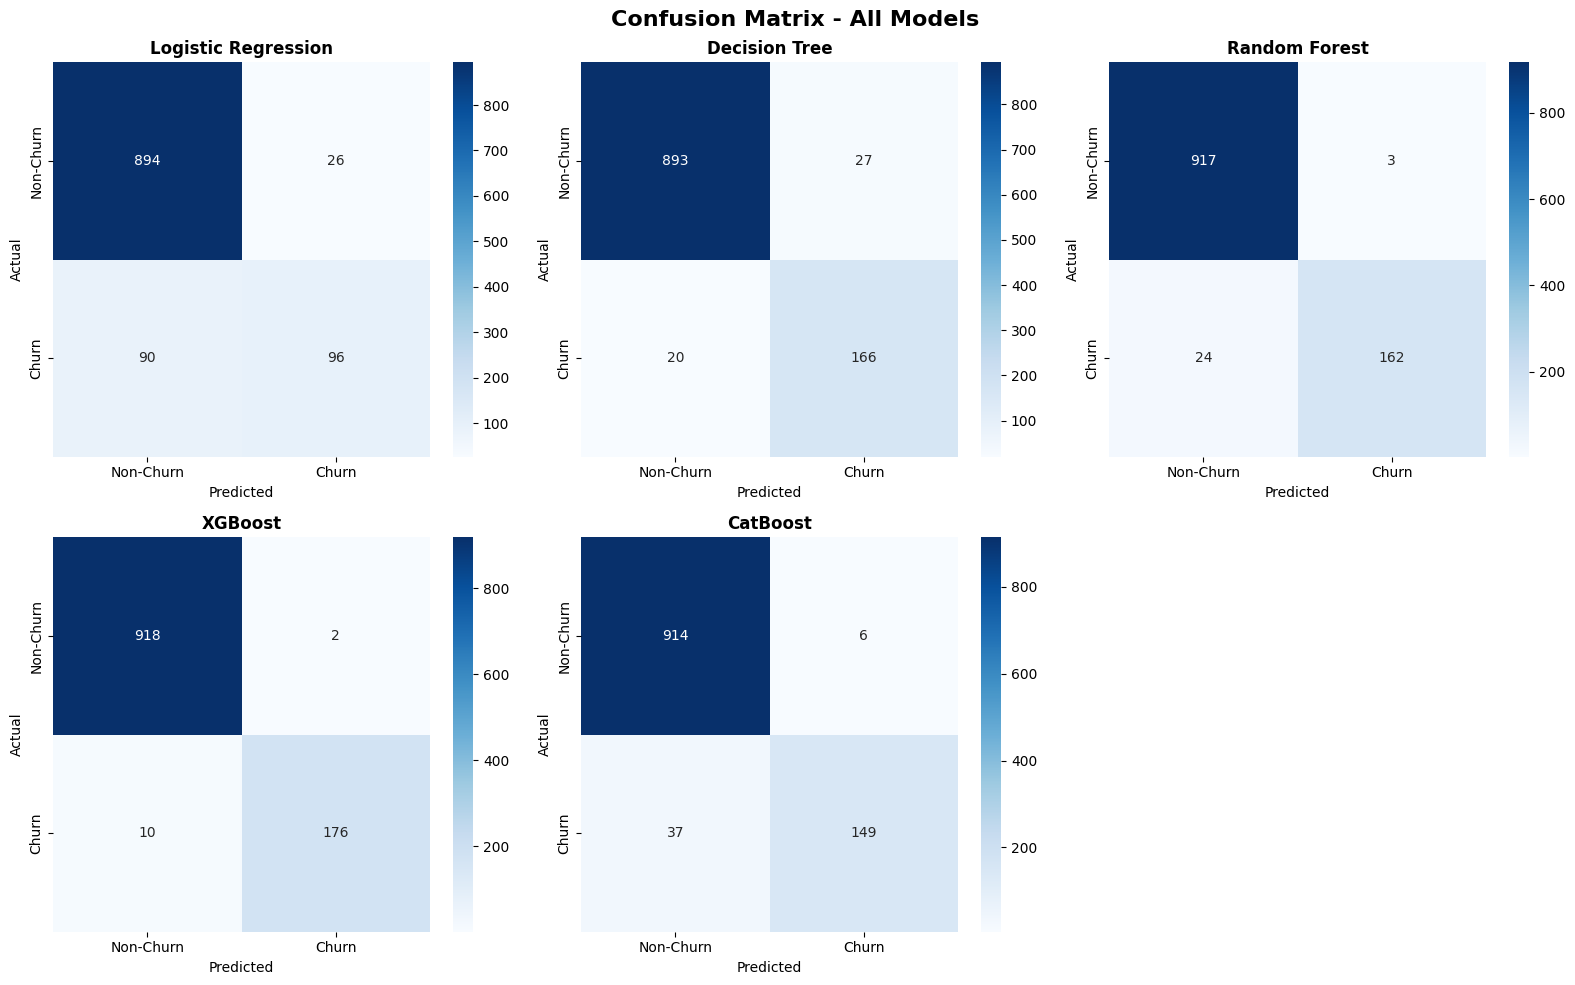

In [6]:
# 5. Confusion Matrix (전체 모델)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Non-Churn', 'Churn'],
                yticklabels=['Non-Churn', 'Churn'])
    axes[i].set_title(f'{name}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

axes[-1].set_visible(False)
plt.suptitle('Confusion Matrix - All Models', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/03_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

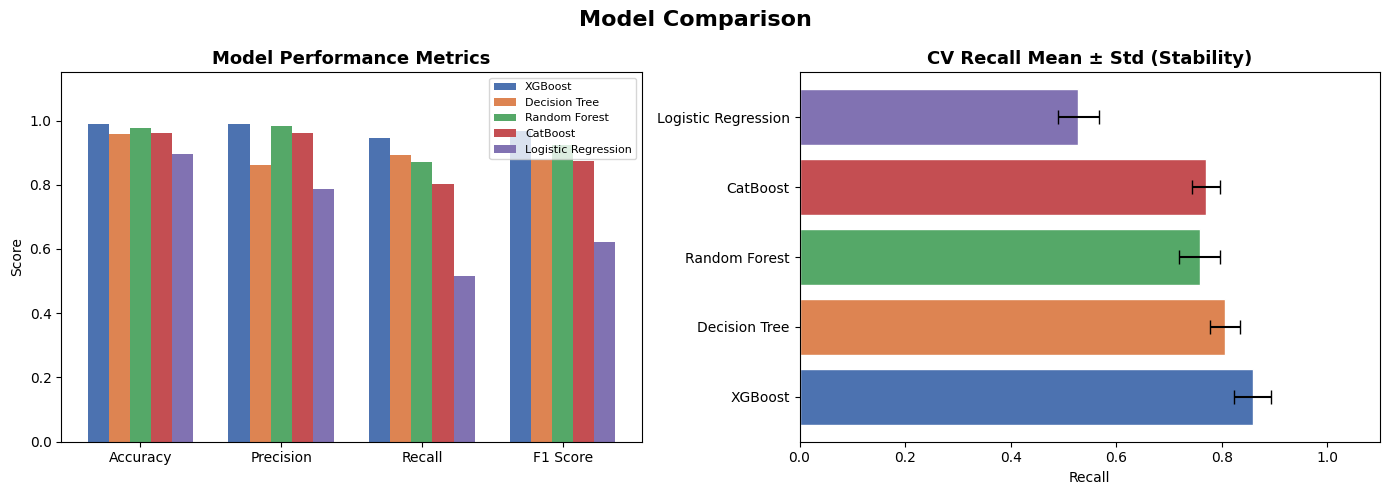

In [7]:
# 6. Recall 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x = np.arange(len(metrics))
width = 0.15
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

for i, (_, row) in enumerate(results_df.iterrows()):
    axes[0].bar(x + i * width, [row[m] for m in metrics],
                width, label=row['Model'], color=colors[i])

axes[0].set_xticks(x + width * 2)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0, 1.15)
axes[0].set_title('Model Performance Metrics', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].set_ylabel('Score')

# CV Recall (stability)
axes[1].barh(results_df['Model'], results_df['CV Recall Mean'],
             xerr=results_df['CV Recall Std'], color=colors, edgecolor='white',
             capsize=5)
axes[1].set_title('CV Recall Mean ± Std (Stability)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_xlim(0, 1.1)

plt.suptitle('Model Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/03_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# 7. 최종 모델 선택 및 저장
import joblib

best_model = models['XGBoost']  # 논문 기준 XGBoost 선택

joblib.dump(best_model, '../outputs/models/xgboost_churn.pkl')
print('✅ Best model saved: outputs/models/xgboost_churn.pkl')
print()
print('=== Best Model: XGBoost ===')
print(f'  Accuracy  : {results_df[results_df["Model"]=="XGBoost"]["Accuracy"].values[0]}')
print(f'  Recall    : {results_df[results_df["Model"]=="XGBoost"]["Recall"].values[0]}')
print(f'  F1 Score  : {results_df[results_df["Model"]=="XGBoost"]["F1 Score"].values[0]}')
print()
print('➡️  Next: 04_xai.ipynb')

✅ Best model saved: outputs/models/xgboost_churn.pkl

=== Best Model: XGBoost ===
  Accuracy  : 0.989
  Recall    : 0.946
  F1 Score  : 0.967

➡️  Next: 04_xai.ipynb
